# Analysis
In this notebook Bebras tasks will be assigned CT tags. (1) <br>
Afterwards, we will start analysing model performances on these tasks (2) by
- Calculating frequency of correct answers (with and without retry)
- Calculate baseline performances for each model
- Compare models amongst each other
- Possibly check whether task perfromance is mediated by certain tags

# 1. Task properties
We will create a data frame which contains all the necessary information about the tasks, including the CT skills. 

In [1]:
#Packages etc
from pathlib import Path
import os
from collections import defaultdict
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

output_path =  Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks\output")
df_path = Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks")


In [2]:
task_names = ["BeckyBee", "FlowerGarden", "StoneFactory", "Strawberries","TheGift", #7+8, easy
              "ClassroomSeating", "ColourTheFrog!", "OhridPearls", "Tic-Tac-Toe","WheatStorage", #7+8, medium
              "ConnectionOfIslands", "FavouriteMovie", "Mysteria", "Ordering1","UndergroundTrainNetwork", #7+8, hard
              "Cipher8", "InLove", "MarysNeighbours", "NutsAndBolts","RugWeaving", #9+10, easy
              "BeaverAI", "HangarCarousel", "OverlappingVillages", "ThePrinter", #9+10, medium
              "CollectingStones", "FavouriteGem", "FourTiles", "Maze", #9+10, hard
              "ColourfulCandles", "ListenAndWalk", "Lists", "MovieNight","Words", #11+12, easy
              "BeaverDam", "JumpingGame", "TreasureBox", #11+12, medium
              "BeaverDatabase", "BeaverGames", "Ordering2", "SeashellsAndPebbles","Virus"] #11+12, hard


In [3]:
task_len = len(task_names)

In [4]:

# Will create an empty data frame and adapt the category information manually

data_empty = {"Task" : task_names,
              "Age": [None] * task_len, 
              "Difficulty" : [None] * task_len,
              "Decomposition": [True] * task_len, 
              "Pattern Recognition": [True] * task_len, 
              "Abstraction": [True] * task_len,
              "Modelling & Simulation" : [True] * task_len,
              "Algorithms": [True] * task_len, 
              "Evaluation": [True] * task_len 
              }

df_empty = pd.DataFrame(data_empty)


In [5]:
df_empty = df_empty.transpose()
print(df_empty.head())

                           0             1             2             3   \
Task                 BeckyBee  FlowerGarden  StoneFactory  Strawberries   
Age                      None          None          None          None   
Difficulty               None          None          None          None   
Decomposition            True          True          True          True   
Pattern Recognition      True          True          True          True   

                          4                 5               6            7   \
Task                 TheGift  ClassroomSeating  ColourTheFrog!  OhridPearls   
Age                     None              None            None         None   
Difficulty              None              None            None         None   
Decomposition           True              True            True         True   
Pattern Recognition     True              True            True         True   

                              8             9   ...          31     32  \


In [19]:
df_path = Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks")
df_empty.to_csv(df_path / "df_empty.csv", encoding = "utf-8", header = False)

I have manually filled in the categories and will load them here. Each category is listed and if a task fulfills this category, it is marked as TRUE 

In [12]:
df_path = Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks")
df_categories = pd.read_csv(df_path / "df_categories.csv", sep = ";")
print(df_categories.head())

                  Task BeckyBee FlowerGarden StoneFactory Strawberries  \
0                  Age      7+8          7+8          7+8          7+8   
1           Difficulty     easy         easy         easy         easy   
2        Decomposition     TRUE         TRUE         TRUE         TRUE   
3  Pattern Recognition    FALSE         TRUE         TRUE        FALSE   
4          Abstraction    FALSE        FALSE         TRUE         TRUE   

  TheGift ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  ...  \
0     7+8              7+8            7+8         7+8         7+8  ...   
1    easy           medium         medium      medium      medium  ...   
2    TRUE             TRUE           TRUE        TRUE        TRUE  ...   
3   FALSE             TRUE          FALSE        TRUE        TRUE  ...   
4    TRUE             TRUE           TRUE       FALSE        TRUE  ...   

  MovieNight  Words BeaverDam JumpingGame TreasureBox BeaverDatabase  \
0      11+12  11+12     11+12       11

**Accuracy Dataframe** <br>
We also need to save a dataframe which contains all the information about each models accuracy, we just can also save this in the previous data frame for simplicity reasons

In [6]:
models = ["Gemini_2.5","Gemini_2.5_retry",
          "Gpt_4o", "Gpt_4o_retry",
          "Gpt_5", "Gpt_5_retry"]

age_groups = ["year_7_8", "year_9_10", "year_11_12"]

difficulties = ["easy", "medium", "hard"]

In [7]:
# This df will only contain accuracy
df_acc = pd.DataFrame(index=models, columns=task_names)

# fill it in 
for age_group in age_groups:
    for difficulty in difficulties:
        for model in models:
            is_retry = model.endswith("_retry")
            base_model = model.replace("_retry", "")

            model_folder = os.path.join(output_path, age_group, difficulty, base_model)
            if not os.path.exists(model_folder):
                continue

            for task in task_names:
                if is_retry:
                    json_file = os.path.join(model_folder, f"{task}_{base_model}_retry.json")
                else:
                    json_file = os.path.join(model_folder, f"{task}_{base_model}.json")

                if not os.path.exists(json_file):
                    continue

                try:
                    with open(json_file, "r") as f:
                        data = json.load(f)
                except json.JSONDecodeError:
                    print(f"Invalid JSON: {json_file}")
                    continue

                #Update
                if data.get("is_correct") is True:
                    df_acc.loc[model, task] = True
                else:
                    df_acc.loc[model, task] = False
                    
print(df_acc)


                 BeckyBee FlowerGarden StoneFactory Strawberries TheGift  \
Gemini_2.5          False         True         True         True    True   
Gemini_2.5_retry    False          NaN          NaN          NaN     NaN   
Gpt_4o              False         True         True        False    True   
Gpt_4o_retry        False          NaN          NaN        False     NaN   
Gpt_5                True         True         True         True    True   
Gpt_5_retry           NaN          NaN          NaN          NaN     NaN   

                 ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  \
Gemini_2.5                   True           True        True       False   
Gemini_2.5_retry              NaN            NaN         NaN       False   
Gpt_4o                      False          False        True       False   
Gpt_4o_retry                 True          False         NaN       False   
Gpt_5                        True           True        True        True   
Gpt_5_retry

In [8]:
df_acc.to_csv(df_path / "df_accuracy.csv", encoding = "utf-8", header = False)

In [9]:
# Lil function to obtain amount of correct answers
def count_correct(df, model):
    return (df.loc[model] == True).sum()

In [10]:
#GPT-4o + retry
gpt4_acc = count_correct(df_acc, "Gpt_4o")
gpt4_retry_acc = gpt4_acc + count_correct(df_acc, "Gpt_4o_retry")

#GPT-5 + retry
gpt5_acc = count_correct(df_acc, "Gpt_5")
gpt5_retry_acc = gpt5_acc + count_correct(df_acc, "Gpt_5_retry")

#Gemini 2.5 + retry
gemini_2_5_acc = count_correct(df_acc, "Gemini_2.5")
gemini_2_5_retry_acc = gemini_2_5_acc + count_correct(df_acc, "Gemini_2.5_retry")

acc_list = [gemini_2_5_acc, gemini_2_5_retry_acc, gpt4_acc, gpt4_retry_acc, gpt5_acc, gpt5_retry_acc]

for model,acc in zip(models, acc_list):
    print("For model ", model, ",", acc, " out of 41 tasks were solved correctly")
    print(f"This means {acc / 41 * 100:.2f}% of tasks were solved correctly")

For model  Gemini_2.5 , 26  out of 41 tasks were solved correctly
This means 63.41% of tasks were solved correctly
For model  Gemini_2.5_retry , 29  out of 41 tasks were solved correctly
This means 70.73% of tasks were solved correctly
For model  Gpt_4o , 10  out of 41 tasks were solved correctly
This means 24.39% of tasks were solved correctly
For model  Gpt_4o_retry , 17  out of 41 tasks were solved correctly
This means 41.46% of tasks were solved correctly
For model  Gpt_5 , 36  out of 41 tasks were solved correctly
This means 87.80% of tasks were solved correctly
For model  Gpt_5_retry , 36  out of 41 tasks were solved correctly
This means 87.80% of tasks were solved correctly


In [13]:
# Categories
# Default values for now are 0

full_df = df_categories

new_rows = []
for model in models:
    row = {"Task": model}
    for col in task_names:
        row[col] = 0
    new_rows.append(row)

models_df = pd.DataFrame(new_rows)
full_df = pd.concat([full_df, models_df], ignore_index= True)

print(full_df.head())

                  Task BeckyBee FlowerGarden StoneFactory Strawberries  \
0                  Age      7+8          7+8          7+8          7+8   
1           Difficulty     easy         easy         easy         easy   
2        Decomposition     TRUE         TRUE         TRUE         TRUE   
3  Pattern Recognition    FALSE         TRUE         TRUE        FALSE   
4          Abstraction    FALSE        FALSE         TRUE         TRUE   

  TheGift ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  ...  \
0     7+8              7+8            7+8         7+8         7+8  ...   
1    easy           medium         medium      medium      medium  ...   
2    TRUE             TRUE           TRUE        TRUE        TRUE  ...   
3   FALSE             TRUE          FALSE        TRUE        TRUE  ...   
4    TRUE             TRUE           TRUE       FALSE        TRUE  ...   

  MovieNight  Words BeaverDam JumpingGame TreasureBox BeaverDatabase  \
0      11+12  11+12     11+12       11

Now iterate through the JSON files and adapt the points based<br>
on task difficulty:<br> <br>
Easy: 6pts<br>
Medium: 9pts<br>
Hard: 12pts<br>
... if the answers are correct

In [14]:
# Mini helper to determine points
def difficultyPoints(difficulty):
    if difficulty == "easy":
        return 6
    elif difficulty == "medium":
        return 9
    elif difficulty == "hard":
        return 12
        
age_groups = ["year_7_8", "year_9_10", "year_11_12"]
difficulties = ["easy", "medium", "hard"]
#reminder: task_names, models

for age_group in age_groups:
    for difficulty in difficulties:
        for model in models:
            # Handle retry naming and file matching
            is_retry = model.endswith("_retry")
            base_model = model.replace("_retry", "")

            # Folder path corresponds to the non-retry model
            model_folder = os.path.join(output_path, age_group, difficulty, base_model)
            if not os.path.exists(model_folder):
                continue

            for task in task_names:
                # Choose correct filename pattern
                if is_retry:
                    json_file = os.path.join(model_folder, f"{task}_{base_model}_retry.json")
                else:
                    json_file = os.path.join(model_folder, f"{task}_{base_model}.json")

                # Skip if JSON doesn’t exist
                if not os.path.exists(json_file):
                    continue

                # Read JSON safely
                try:
                    with open(json_file, "r") as f:
                        data = json.load(f)
                except json.JSONDecodeError:
                    print(f"Invalid JSON: {json_file}")
                    continue

                # Check correctness and assign points
                if data.get("is_correct") == True:
                    points = difficultyPoints(difficulty)
                    full_df.loc[full_df["Task"] == model, task] = points
                else:
                    # remains 0
                    pass

print(full_df.head())

                  Task BeckyBee FlowerGarden StoneFactory Strawberries  \
0                  Age      7+8          7+8          7+8          7+8   
1           Difficulty     easy         easy         easy         easy   
2        Decomposition     TRUE         TRUE         TRUE         TRUE   
3  Pattern Recognition    FALSE         TRUE         TRUE        FALSE   
4          Abstraction    FALSE        FALSE         TRUE         TRUE   

  TheGift ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  ...  \
0     7+8              7+8            7+8         7+8         7+8  ...   
1    easy           medium         medium      medium      medium  ...   
2    TRUE             TRUE           TRUE        TRUE        TRUE  ...   
3   FALSE             TRUE          FALSE        TRUE        TRUE  ...   
4    TRUE             TRUE           TRUE       FALSE        TRUE  ...   

  MovieNight  Words BeaverDam JumpingGame TreasureBox BeaverDatabase  \
0      11+12  11+12     11+12       11

In [15]:
print(full_df.head())
full_df.to_csv(df_path / "full_df.csv", encoding = "utf-8", header= True)

                  Task BeckyBee FlowerGarden StoneFactory Strawberries  \
0                  Age      7+8          7+8          7+8          7+8   
1           Difficulty     easy         easy         easy         easy   
2        Decomposition     TRUE         TRUE         TRUE         TRUE   
3  Pattern Recognition    FALSE         TRUE         TRUE        FALSE   
4          Abstraction    FALSE        FALSE         TRUE         TRUE   

  TheGift ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  ...  \
0     7+8              7+8            7+8         7+8         7+8  ...   
1    easy           medium         medium      medium      medium  ...   
2    TRUE             TRUE           TRUE        TRUE        TRUE  ...   
3   FALSE             TRUE          FALSE        TRUE        TRUE  ...   
4    TRUE             TRUE           TRUE       FALSE        TRUE  ...   

  MovieNight  Words BeaverDam JumpingGame TreasureBox BeaverDatabase  \
0      11+12  11+12     11+12       11

**Time Dataframe** <br>
Saves the time each model (+ retry) took for each task 

In [16]:
models = ["Gemini_2.5","Gemini_2.5_retry",
          "Gpt_4o", "Gpt_4o_retry",
          "Gpt_5", "Gpt_5_retry"]

full_df_time = pd.DataFrame(index=models, columns=task_names)
print(full_df_time.head())

                 BeckyBee FlowerGarden StoneFactory Strawberries TheGift  \
Gemini_2.5            NaN          NaN          NaN          NaN     NaN   
Gemini_2.5_retry      NaN          NaN          NaN          NaN     NaN   
Gpt_4o                NaN          NaN          NaN          NaN     NaN   
Gpt_4o_retry          NaN          NaN          NaN          NaN     NaN   
Gpt_5                 NaN          NaN          NaN          NaN     NaN   

                 ClassroomSeating ColourTheFrog! OhridPearls Tic-Tac-Toe  \
Gemini_2.5                    NaN            NaN         NaN         NaN   
Gemini_2.5_retry              NaN            NaN         NaN         NaN   
Gpt_4o                        NaN            NaN         NaN         NaN   
Gpt_4o_retry                  NaN            NaN         NaN         NaN   
Gpt_5                         NaN            NaN         NaN         NaN   

                 WheatStorage  ... MovieNight Words BeaverDam JumpingGame  \
Gemini_2.

In [17]:
# Iterate through each folder and save the time the models took for each task
        
age_groups = ["year_7_8", "year_9_10", "year_11_12"]
difficulties = ["easy", "medium", "hard"]
#reminder: task_names, models

for age_group in age_groups:
    for difficulty in difficulties:
        for base_model in [m for m in models if not m.endswith("_retry")]:

            model_folder = os.path.join(output_path, age_group, difficulty, base_model)
            if not os.path.exists(model_folder):
                continue

            for task in task_names:

                base_file = os.path.join(
                    model_folder, f"{task}_{base_model}.json"
                )

                if not os.path.exists(base_file):
                    continue

                # --- Read base attempt ---
                try:
                    with open(base_file, "r") as f:
                        base_data = json.load(f)
                except json.JSONDecodeError:
                    continue

                # Always save base time
                full_df_time.loc[base_model, task] = base_data.get("response_time_sec")

                # --- If incorrect, handle retry ---
                if base_data.get("is_correct") is not True:
                    retry_file = os.path.join(
                        model_folder, f"{task}_{base_model}_retry.json"
                    )

                    if not os.path.exists(retry_file):
                        continue

                    try:
                        with open(retry_file, "r") as f:
                            retry_data = json.load(f)
                    except json.JSONDecodeError:
                        continue

                    full_df_time.loc[f"{base_model}_retry", task] = retry_data.get(
                        "response_time_sec"
                    )

#print(full_df_time)

In [18]:
# save df to computer
full_df_time.to_csv(df_path / "full_df_time.csv", encoding = "utf-8", header= True)

# 2. Performance analysis 

In this step we will determine the accuracy based on model/ difficulty/ age/ categories etc.

In [21]:
#so that we don't have to re-run every piece of code
df_path = Path(r"C:\Users\schul\Documents\uni\Master_Kogni\Praktikum\Tasks")
models = [
    "Gemini_2.5", "Gemini_2.5_retry",
    "Gpt_4o", "Gpt_4o_retry",
    "Gpt_5", "Gpt_5_retry"
]

full_df = pd.read_csv(df_path / "full_df.csv", sep = ",")
full_df = full_df.iloc[: , 1:]
full_df = full_df.set_index("Task")
full_df.loc[models] = (
    full_df.loc[models]
    .apply(pd.to_numeric, errors="coerce")
)

full_df_time = pd.read_csv(df_path / "full_df_time.csv", sep = ",", index_col= 0)

full_df.loc[models] = full_df.loc[models].apply(pd.to_numeric, errors="coerce")
full_df_time.loc[models] = full_df_time.loc[models].apply(pd.to_numeric, errors="coerce")



#print(full_df.head())
#print(full_df_time.head())

In [22]:
print(full_df)
#print(full_df_time)

                       BeckyBee FlowerGarden StoneFactory Strawberries  \
Task                                                                     
Age                         7+8          7+8          7+8          7+8   
Difficulty                 easy         easy         easy         easy   
Decomposition              TRUE         TRUE         TRUE         TRUE   
Pattern Recognition       FALSE         TRUE         TRUE        FALSE   
Abstraction               FALSE        FALSE         TRUE         TRUE   
Modelling & Simulation     TRUE         TRUE         TRUE         TRUE   
Algorithms                 TRUE         TRUE         TRUE         TRUE   
Evaluation                 TRUE         TRUE         TRUE         TRUE   
Gemini_2.5                    0            6            6            6   
Gemini_2.5_retry              0            0            0            0   
Gpt_4o                        0            6            6            0   
Gpt_4o_retry                  0       

In [23]:
# Small helper function to calculate all points

def accuracyFor(model, age=None, difficulty=None):
    cols = full_df.columns

    # --- Age filter ---
    if age is None:
        age_mask = pd.Series(True, index=cols)
    elif isinstance(age, (list, tuple, set)):
        age_mask = full_df.loc["Age"].isin(age)
    else:
        age_mask = full_df.loc["Age"] == age

    # --- Difficulty filter ---
    if difficulty is None:
        diff_mask = pd.Series(True, index=cols)
    elif isinstance(difficulty, (list, tuple, set)):
        diff_mask = full_df.loc["Difficulty"].isin(difficulty)
    else:
        diff_mask = full_df.loc["Difficulty"] == difficulty

    # --- Apply mask and sum up points ---
    vals = full_df.loc[model, age_mask & diff_mask]
    return pd.to_numeric(vals, errors="coerce").sum()



In [24]:
# Function tests
print(accuracyFor("Gpt_4o", age ="9+10", difficulty="medium"))
print(accuracyFor("Gpt_4o", age="7+8"))
print(accuracyFor("Gpt_4o", difficulty="medium"))
print(accuracyFor("Gpt_4o", age =["7+8","9+10"], difficulty="medium"))
print(accuracyFor("Gemini_2.5"))

9
39
27
18
225


**Plotting results**


In [25]:
# Reminder: Max achievable points: 366

# Accuracy values for each model + retry
model_vals = {"Gpt_4o": accuracyFor("Gpt_4o"),
              "Gpt_5": accuracyFor("Gpt_5"),
              "Gemini_2.5": accuracyFor("Gemini_2.5")}

model_retry_vals = {"Gpt_4o_retry": accuracyFor("Gpt_4o_retry") + accuracyFor("Gpt_4o"),
                    "Gpt_5_retry": accuracyFor("Gpt_5_retry") + accuracyFor("Gpt_5"),
                    "Gemini_2.5_retry": accuracyFor("Gemini_2.5_retry")+ accuracyFor("Gemini_2.5")}

print(model_vals)
print(model_retry_vals)

{'Gpt_4o': 81, 'Gpt_5': 321, 'Gemini_2.5': 225}
{'Gpt_4o_retry': 132, 'Gpt_5_retry': 321, 'Gemini_2.5_retry': 252}


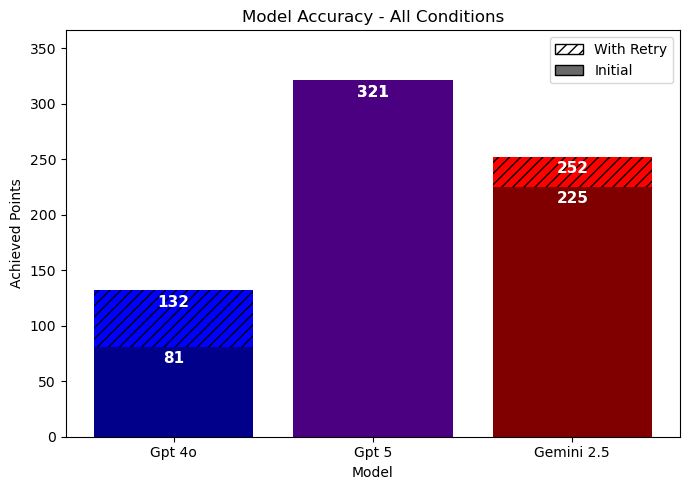

In [26]:
# Plot the accuracy for each model + retry

labels = [m.replace("_", " ") for m in model_vals.keys()]

labels = [m.replace("_", " ") for m in model_vals.keys()]

base_colors  = ["darkblue", "indigo", "maroon"]
light_colors = ["blue", "orchid", "red"]

plt.figure(figsize=(7,5))

# Retry bars first (background)
plt.bar(labels, model_retry_vals.values(), color=light_colors, hatch="///", label="With Retry")

# Initial bars on top (foreground)
plt.bar(labels, model_vals.values(), color=base_colors, label="Initial")

# Add text labels
for i, val in enumerate(model_vals.values()):
    plt.text(i, val - 4 , str(val), ha="center", va="top", fontsize=11, 
             weight = "bold", color = "white")
for i, val in enumerate(model_retry_vals.values()):
    plt.text(i, val - 4, str(val), ha="center", va="top", fontsize=11, 
             weight = "bold", color = "white")

plt.ylabel("Achieved Points")
plt.xlabel("Model")
plt.title("Model Accuracy - All Conditions")
plt.ylim(0, 366)

# Custom legend without misleading colors
legend_handles = [
    mpatches.Patch(facecolor="none", edgecolor="black", hatch="///", label="With Retry"),
    mpatches.Patch(facecolor="dimgrey", edgecolor="black", label="Initial")
]
plt.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [27]:
# Accuracy values for each model + retry, save variables for future
Gpt4o_easy = accuracyFor("Gpt_4o", difficulty="easy")
Gpt4o_medium = accuracyFor("Gpt_4o", difficulty="medium")
Gpt4o_hard  = accuracyFor("Gpt_4o", difficulty="hard")
Gpt4o_easy_retry = accuracyFor("Gpt_4o_retry", difficulty="easy")
Gpt4o_medium_retry = accuracyFor("Gpt_4o_retry", difficulty="medium")
Gpt4o_hard_retry  = accuracyFor("Gpt_4o_retry", difficulty="hard")

Gpt5_easy = accuracyFor("Gpt_5", difficulty="easy")
Gpt5_medium = accuracyFor("Gpt_5", difficulty="medium")
Gpt5_hard  = accuracyFor("Gpt_5", difficulty="hard")
Gpt5_easy_retry = accuracyFor("Gpt_5_retry", difficulty="easy")
Gpt5_medium_retry = accuracyFor("Gpt_5_retry", difficulty="medium")
Gpt5_hard_retry  = accuracyFor("Gpt_5_retry", difficulty="hard")

Gemini_2_5_easy = accuracyFor("Gemini_2.5", difficulty="easy")
Gemini_2_5_medium = accuracyFor("Gemini_2.5", difficulty="medium")
Gemini_2_5_hard  = accuracyFor("Gemini_2.5", difficulty="hard")
Gemini_2_5_easy_retry = accuracyFor("Gemini_2.5_retry", difficulty="easy")
Gemini_2_5_medium_retry = accuracyFor("Gemini_2.5_retry", difficulty="medium")
Gemini_2_5_hard_retry  = accuracyFor("Gemini_2.5_retry", difficulty="hard")

# Max points each block
max_pts_easy = 30 + 30 + 30 # We use all easy tasks
max_pts_medium = 45 + 36 + 27 # We omitted 3 tasks
mx_pts_hard = 60 + 48 + 60 # We omitted 1 task

# Save in dict for plotting 
# We need to make the points comparable to one another, which is why we divide by max. points
model_vals_difficulty = {"Gpt_4o": [Gpt4o_easy / max_pts_easy,
                                    Gpt4o_medium / max_pts_medium,
                                    Gpt4o_hard / mx_pts_hard],
                         "Gpt_5": [Gpt5_easy / max_pts_easy,
                                    Gpt5_medium / max_pts_medium,
                                    Gpt5_hard / mx_pts_hard],
                         "Gemini_2.5": [Gemini_2_5_easy / max_pts_easy,
                                        Gemini_2_5_medium / max_pts_medium,
                                        Gemini_2_5_hard / mx_pts_hard]}

model_retry_vals_difficulty  = {"Gpt_4o_retry": [(Gpt4o_easy + Gpt4o_easy_retry) / max_pts_easy,
                                                 (Gpt4o_medium  + Gpt4o_medium_retry) / max_pts_medium,
                                                 (Gpt4o_hard + Gpt4o_hard_retry) / mx_pts_hard],
                                "Gpt_5_retry": [(Gpt5_easy + Gpt5_easy_retry) / max_pts_easy,
                                                 (Gpt5_medium  + Gpt5_medium_retry) / max_pts_medium,
                                                 (Gpt5_hard + Gpt5_hard_retry) / mx_pts_hard],
                                "Gemini_2.5_retry": [(Gemini_2_5_easy + Gemini_2_5_easy_retry) / max_pts_easy,
                                                 (Gemini_2_5_medium  + Gemini_2_5_medium_retry) / max_pts_medium,
                                                 (Gemini_2_5_hard + Gemini_2_5_hard_retry) / mx_pts_hard]}



print(model_vals_difficulty)
print(model_retry_vals_difficulty)

{'Gpt_4o': [0.3333333333333333, 0.25, 0.14285714285714285], 'Gpt_5': [0.8666666666666667, 0.9166666666666666, 0.8571428571428571], 'Gemini_2.5': [0.7333333333333333, 0.5833333333333334, 0.5714285714285714]}
{'Gpt_4o_retry': [0.6666666666666666, 0.3333333333333333, 0.21428571428571427], 'Gpt_5_retry': [0.8666666666666667, 0.9166666666666666, 0.8571428571428571], 'Gemini_2.5_retry': [0.8, 0.6666666666666666, 0.6428571428571429]}


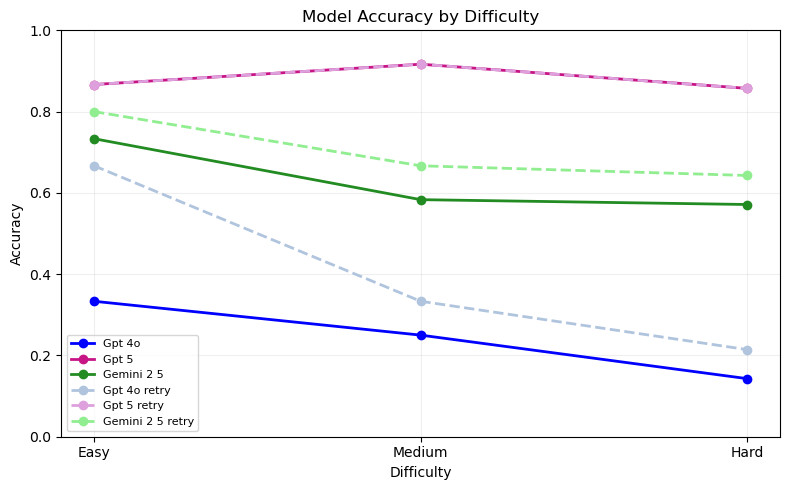

In [28]:
# Plot model x difficulty x accuracy

difficulties = ["Easy", "Medium", "Hard"]

# Colors matching your previous palette (same order: Gpt_4o, Gpt_5, Gemini)
base_colors  = ["blue", "mediumvioletred", "forestgreen"]
light_colors = ["lightsteelblue", "plum", "lightgreen"]  # used for dotted retry lines

plt.figure(figsize=(8,5))

# --- Plot initial model performance ---
for (model, vals), color in zip(model_vals_difficulty.items(), base_colors):
    label = model.replace("_", " ").replace(".", " ")
    plt.plot(difficulties, vals, marker="o", color=color, linestyle="-", linewidth=2, label=label)

# --- Plot retry performance (dotted lines) ---
for (model, vals), color in zip(model_retry_vals_difficulty.items(), light_colors):
    label = model.replace("_", " ").replace(".", " ") 
    plt.plot(difficulties, vals, marker="o", color=color, linestyle="--", linewidth=2, label=label)

plt.ylabel("Accuracy")
plt.xlabel("Difficulty")
plt.title("Model Accuracy by Difficulty")
plt.ylim(0,1)
plt.grid(alpha=0.2)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [29]:
# Plot model x age x accuracy

# Accuracy values for each model + retry, save variables for future
Gpt4o_years_7_8 = accuracyFor("Gpt_4o", age="7+8")
Gpt4o_years_9_10 = accuracyFor("Gpt_4o", age="9+10")
Gpt4o_years_11_12  = accuracyFor("Gpt_4o", age="11+12")
Gpt4o_years_7_8_retry = accuracyFor("Gpt_4o_retry", age="7+8")
Gpt4o_years_9_10_retry = accuracyFor("Gpt_4o_retry", age="9+10")
Gpt4o_years_11_12_retry  = accuracyFor("Gpt_4o_retry", age="11+12")

Gpt5_years_7_8 = accuracyFor("Gpt_5", age="7+8")
Gpt5_years_9_10 = accuracyFor("Gpt_5", age="9+10")
Gpt5_years_11_12  = accuracyFor("Gpt_5", age="11+12")
Gpt5_years_7_8_retry = accuracyFor("Gpt_5_retry", age="7+8")
Gpt5_years_9_10_retry = accuracyFor("Gpt_5_retry", age="9+10")
Gpt5_years_11_12_retry  = accuracyFor("Gpt_5_retry", age="11+12")

Gemini_2_5_years_7_8 = accuracyFor("Gemini_2.5", age="7+8")
Gemini_2_5_years_9_10 = accuracyFor("Gemini_2.5", age="9+10")
Gemini_2_5_years_11_12  = accuracyFor("Gemini_2.5", age="11+12")
Gemini_2_5_years_7_8_retry = accuracyFor("Gemini_2.5_retry", age="7+8")
Gemini_2_5_years_9_10_retry = accuracyFor("Gemini_2.5_retry", age="9+10")
Gemini_2_5_years_11_12_retry  = accuracyFor("Gemini_2.5_retry", age="11+12")

# Max points each block
max_pts_years_7_8 = 30 + 45 + 60 # We use all 7-8 tasks
max_pts_years_9_10 = 30 + 36 + 48 # We omitted 2 tasks
mx_pts_years_11_12 = 30 + 27 + 60 # We omitted 2 task

# Save in dict for plotting 
# We need to make the points comparable to one another, which is why we divide by max. points
model_vals_ages = {"Gpt_4o": [Gpt4o_years_7_8 / max_pts_years_7_8,
                                    Gpt4o_years_9_10 / max_pts_years_9_10,
                                    Gpt4o_years_11_12 / mx_pts_years_11_12],
                         "Gpt_5": [Gpt5_years_7_8 / max_pts_years_7_8,
                                    Gpt5_years_9_10 / max_pts_years_9_10,
                                    Gpt5_years_11_12 / mx_pts_years_11_12],
                         "Gemini_2.5": [Gemini_2_5_years_7_8 / max_pts_years_7_8,
                                        Gemini_2_5_years_9_10 / max_pts_years_9_10,
                                        Gemini_2_5_years_11_12 / mx_pts_years_11_12]}

model_retry_vals_ages  = {"Gpt_4o_retry": [(Gpt4o_years_7_8 + Gpt4o_years_7_8_retry) / max_pts_years_7_8,
                                                 (Gpt4o_years_9_10 + Gpt4o_years_9_10_retry) / max_pts_years_9_10,
                                                 (Gpt4o_years_11_12 + Gpt4o_years_11_12_retry) / mx_pts_years_11_12],
                                "Gpt_5_retry": [(Gpt5_years_7_8 + Gpt5_years_7_8_retry) / max_pts_years_7_8,
                                                 (Gpt5_years_9_10  + Gpt5_years_9_10_retry) / max_pts_years_9_10,
                                                 (Gpt5_years_11_12 + Gpt5_years_11_12_retry) / mx_pts_years_11_12],
                                "Gemini_2.5_retry": [(Gemini_2_5_years_7_8 + Gemini_2_5_years_7_8_retry) / max_pts_years_7_8,
                                                 (Gemini_2_5_years_9_10  + Gemini_2_5_years_9_10_retry) / max_pts_years_9_10,
                                                 (Gemini_2_5_years_11_12 + Gemini_2_5_years_11_12_retry) / mx_pts_years_11_12]}



print(model_vals_ages)
print(model_retry_vals_ages)

{'Gpt_4o': [0.28888888888888886, 0.07894736842105263, 0.28205128205128205], 'Gpt_5': [0.9111111111111111, 0.8157894736842105, 0.8974358974358975], 'Gemini_2.5': [0.7333333333333333, 0.42105263157894735, 0.6666666666666666]}
{'Gpt_4o_retry': [0.4444444444444444, 0.23684210526315788, 0.38461538461538464], 'Gpt_5_retry': [0.9111111111111111, 0.8157894736842105, 0.8974358974358975], 'Gemini_2.5_retry': [0.7333333333333333, 0.5789473684210527, 0.7435897435897436]}


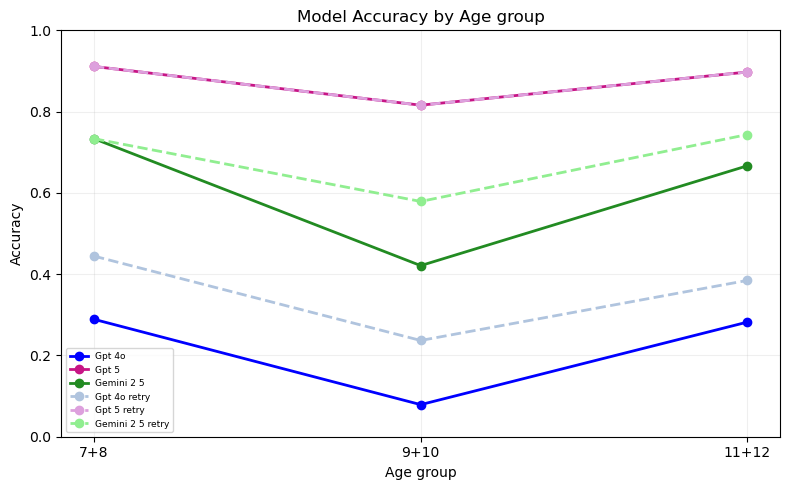

In [30]:
ages = ["7+8", "9+10", "11+12"]

# Colors matching the previous ones
base_colors  = ["blue", "mediumvioletred", "forestgreen"]
light_colors = ["lightsteelblue", "plum", "lightgreen"]  # used for dotted retry lines

plt.figure(figsize=(8,5))

# --- Plot initial model performance ---
for (model, vals), color in zip(model_vals_ages.items(), base_colors):
    label = model.replace("_", " ").replace(".", " ")
    plt.plot(ages, vals, marker="o", color=color, linestyle="-", linewidth=2, label=label)

# --- Plot retry performance (dotted lines) ---
for (model, vals), color in zip(model_retry_vals_ages.items(), light_colors):
    label = model.replace("_", " ").replace(".", " ") 
    plt.plot(ages, vals, marker="o", color=color, linestyle="--", linewidth=2, label=label)

plt.ylabel("Accuracy")
plt.xlabel("Age group")
plt.title("Model Accuracy by Age group")
plt.ylim(0,1)
plt.grid(alpha=0.2)
plt.legend(fontsize=6.5)
plt.tight_layout()
plt.show()

**Time analysis**
I want:
- determine outliers
- average time each model took per task (with error bars, boxplot)

In [31]:
# determines the max/ min times for each model
maxTime_Gemini_2_5 = full_df_time.loc["Gemini_2.5"].sort_values(ascending = False).head(5)
maxTime_Gemini_2_5_retry = full_df_time.loc["Gemini_2.5_retry"].sort_values(ascending = False).head(5)
minTime_Gemini_2_5 = full_df_time.loc["Gemini_2.5"].sort_values().head(5)
minTime_Gemini_2_5_retry = full_df_time.loc["Gemini_2.5_retry"].sort_values().head(5)
maxTime_Gpt_4o = full_df_time.loc["Gpt_4o"].sort_values(ascending = False).head(5)
maxTime_Gpt_4o_retry = full_df_time.loc["Gpt_4o_retry"].sort_values(ascending = False).head(5)
minTime_Gpt_4o = full_df_time.loc["Gpt_4o"].sort_values().head(5)
minTime_Gpt_4o_retry = full_df_time.loc["Gpt_4o_retry"].sort_values().head(5)
maxTime_Gpt_5 = full_df_time.loc["Gpt_5"].sort_values(ascending = False).head(7)
maxTime_Gpt_5_retry = full_df_time.loc["Gpt_5_retry"].sort_values(ascending = False).head(5)
minTime_Gpt_5 = full_df_time.loc["Gpt_5"].sort_values().head(5)
minTime_Gpt_5_retry = full_df_time.loc["Gpt_5_retry"].sort_values().head(5)

In [32]:
#Gemini 2.5 times
print("Gemini 2.5 max times:")
print(maxTime_Gemini_2_5)
print("Gemini 2.5 min times:")
print(minTime_Gemini_2_5)

Gemini 2.5 max times:
ListenAndWalk          231.644
FourTiles              124.179
CollectingStones       122.123
BeckyBee               113.169
SeashellsAndPebbles     97.588
Name: Gemini_2.5, dtype: float64
Gemini 2.5 min times:
Lists              2.715
Tic-Tac-Toe        3.746
StoneFactory       6.138
MarysNeighbours    8.016
TheGift            9.412
Name: Gemini_2.5, dtype: float64


In [33]:
#Gemini 2.5 RETRY times
print("Gemini 2.5 RETRY max times:")
print(maxTime_Gemini_2_5_retry)
print("Gemini 2.5 RETRY min times:")
print(minTime_Gemini_2_5_retry)

Gemini 2.5 RETRY max times:
CollectingStones    124.578
FourTiles            94.416
WheatStorage         90.655
BeckyBee             81.219
ListenAndWalk        77.591
Name: Gemini_2.5_retry, dtype: float64
Gemini 2.5 RETRY min times:
MarysNeighbours        13.264
Tic-Tac-Toe            18.359
BeaverDatabase         34.112
JumpingGame            36.879
OverlappingVillages    50.966
Name: Gemini_2.5_retry, dtype: float64


In [34]:
# GPT 4o times
print("GPT 4o max times:")
print(maxTime_Gpt_4o)
print("GPT 4o min times:")
print(minTime_Gpt_4o)

GPT 4o max times:
OverlappingVillages        26.642
UndergroundTrainNetwork    22.552
Virus                      21.278
ClassroomSeating           20.032
Words                      19.724
Name: Gpt_4o, dtype: float64
GPT 4o min times:
Lists           4.385
Maze            8.319
StoneFactory    8.463
BeaverDam       9.159
Ordering1       9.192
Name: Gpt_4o, dtype: float64


In [35]:
# GPT 4o RETRY times
print("GPT 4o max times:")
print(maxTime_Gpt_4o_retry)
print("GPT 4o min times:")
print(minTime_Gpt_4o_retry)

GPT 4o max times:
FavouriteMovie         23.910
WheatStorage           23.013
Cipher8                22.107
InLove                 20.229
SeashellsAndPebbles    16.820
Name: Gpt_4o_retry, dtype: float64
GPT 4o min times:
Virus          1.053
ThePrinter     6.597
MovieNight     6.690
RugWeaving     7.582
BeaverGames    8.031
Name: Gpt_4o_retry, dtype: float64


In [36]:
# GPT 5 times
print("GPT 5 max times:")
print(maxTime_Gpt_5)
print("GPT 5 min times:")
print(minTime_Gpt_5)

GPT 5 max times:
FourTiles              906.393
CollectingStones       832.096
Maze                   424.524
JumpingGame            280.035
SeashellsAndPebbles    245.372
ListenAndWalk          186.319
WheatStorage           176.394
Name: Gpt_5, dtype: float64
GPT 5 min times:
Lists            8.650
InLove          11.647
StoneFactory    12.026
RugWeaving      13.993
TheGift         15.615
Name: Gpt_5, dtype: float64


In [37]:
# GPT 5 RETRY times
print("GPT 5 max times:")
print(maxTime_Gpt_5_retry)
print("GPT 5 min times:")
print(minTime_Gpt_5_retry)

GPT 5 max times:
SeashellsAndPebbles    154.486
NutsAndBolts           129.360
OverlappingVillages     85.977
Mysteria                75.993
MarysNeighbours         38.856
Name: Gpt_5_retry, dtype: float64
GPT 5 min times:
MarysNeighbours         38.856
Mysteria                75.993
OverlappingVillages     85.977
NutsAndBolts           129.360
SeashellsAndPebbles    154.486
Name: Gpt_5_retry, dtype: float64


**Boxplot** 
<br>
We can see there are quite the big disparities with the times, that's why we need to visualize it
<br>
Especially "Four Tiles" and "Collecting Stones" for GPT 5 seem

C:\Users\schul\AppData\Local\Temp\ipykernel_22132\1562117240.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


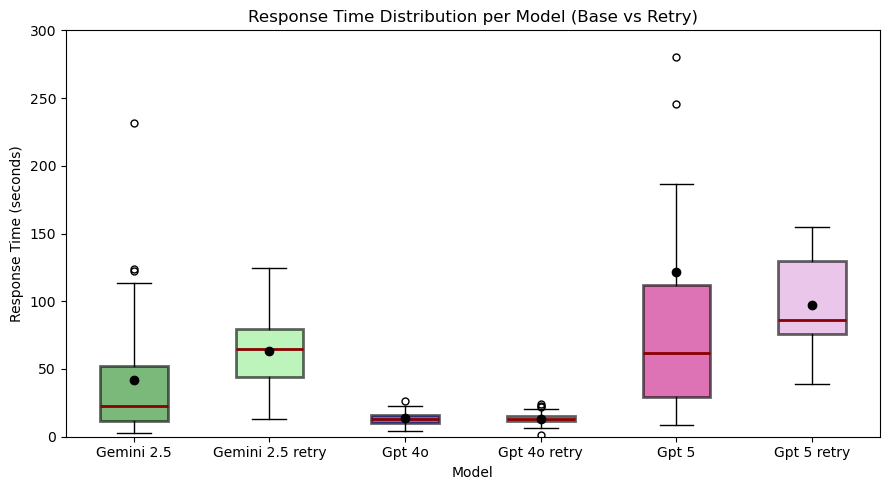

In [38]:
#Extremes cut off at >300s

colors = [
    "forestgreen", "lightgreen",       # Gemini
    "blue", "lightsteelblue",           # Gpt 4o
    "mediumvioletred", "plum"           # Gpt 5
]

data = [
    full_df_time.loc[m].dropna().values
    for m in models
]

plt.figure(figsize=(9, 5))

box = plt.boxplot(
    data,
    labels=[m.replace("_", " ") for m in models],
    showmeans=True,
    showfliers=True,
    patch_artist=True,
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="black",
        markersize=5,
        linestyle="none"
    )
)

# Color boxes
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2)

# Medians
for median in box["medians"]:
    median.set_color("darkred")
    median.set_linewidth(2)

# Means
for mean in box["means"]:
    mean.set_marker("o")
    mean.set_markerfacecolor("black")
    mean.set_markeredgecolor("black")
    mean.set_markersize(6)

# ---- CUTOFF HERE ----
plt.ylim(0, 300)



plt.ylabel("Response Time (seconds)")
plt.xlabel("Model")
plt.title("Response Time Distribution per Model (Base vs Retry)")

plt.tight_layout()
plt.show()



C:\Users\schul\AppData\Local\Temp\ipykernel_22132\4014540934.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


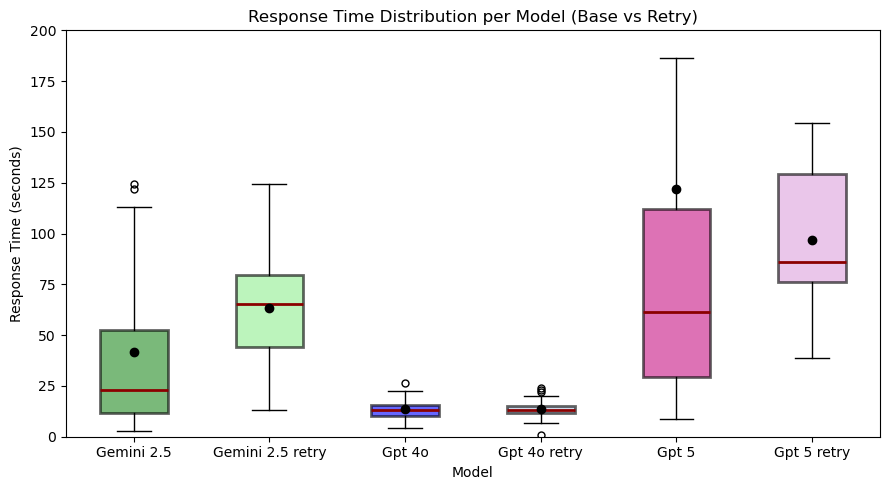

In [39]:
#Extremes cut off at >200s

colors = [
    "forestgreen", "lightgreen",       # Gemini
    "blue", "lightsteelblue",           # Gpt 4o
    "mediumvioletred", "plum"           # Gpt 5
]

data = [
    full_df_time.loc[m].dropna().values
    for m in models
]

plt.figure(figsize=(9, 5))

box = plt.boxplot(
    data,
    labels=[m.replace("_", " ") for m in models],
    showmeans=True,
    showfliers=True,
    patch_artist=True,
    flierprops=dict(
        marker="o",
        markerfacecolor="none",
        markeredgecolor="black",
        markersize=5,
        linestyle="none"
    )
)

# Color boxes
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2)

# Medians
for median in box["medians"]:
    median.set_color("darkred")
    median.set_linewidth(2)

# Means
for mean in box["means"]:
    mean.set_marker("o")
    mean.set_markerfacecolor("black")
    mean.set_markeredgecolor("black")
    mean.set_markersize(6)

# ---- CUTOFF HERE ----
plt.ylim(0, 200)



plt.ylabel("Response Time (seconds)")
plt.xlabel("Model")
plt.title("Response Time Distribution per Model (Base vs Retry)")

plt.tight_layout()
plt.show()



In [40]:
n_retries = full_df_time.loc[full_df_time.index.str.endswith("_retry")].notna().sum().sum()
print(n_retries)

51
